<a href="https://colab.research.google.com/github/katarinako01/DL_image_segmentation/blob/main/image_segmentation_training_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Urban Scene Segmentation with U-Net — Part 2: Model training and evaluation

## Task overview
Create a semantic segmentation model for classes of choice (chosen: urban scenes).

Implementation using a U-Net architecture with ResNet34 encoder. The model classifies each pixel into one of 6 classes: Background, Person, Car, Bus, Traffic light, and Skyscraper.

## This notebook
Model development and evaluation:
- PyTorch Dataset and DataLoaders
- U-Net architecture (ResNet34 encoder + custom decoder)
- Training with Dice + Weighted Cross-Entropy loss
- Evaluation metrics: Accuracy, Precision, Recall, F1
- Benchmark comparison against Segment Anything Model (SAM)

## Data
Prepared (and explored) in Part 1 (https://colab.research.google.com/drive/1c9RHT8EKqAtFu9xUQouoggKCPiR_CBEh?usp=sharing):
- **Train:** 2772 images
- **Val:** 308 images
- **Test:** 100 images

In [ ]:
# libraries
import json
from google.colab import drive
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import random
from multiprocessing import Pool
import functools
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# define random seed for reproductibility
# note: since I am running this code by cell and not all at once -> will be setting the seed wherever it is needed at the top of the cell
# usage: just call set_seed() where needed; if some other value (not 123) should be used -> update in the parentheses, e.g. set_seed(42)
def set_seed(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
# splits
with open("/content/drive/MyDrive/splits.json") as f:
    splits = json.load(f)

train_ids = splits["train_ids"]
val_ids = splits["val_ids"]
test_ids = splits["test_ids"]
TARGET_CLASSES = splits["target_classes"]

# paths
IMAGES_DIR = "/content/drive/MyDrive/images"
DENSE_MASKS_DIR = "/content/drive/MyDrive/dense_masks"

**Preprocessing:**
- Resize to fixed dimensions (256×256) for batching
- Normalize using ImageNet statistics (required for pretrained ResNet encoder, source: https://docs.pytorch.org/vision/0.12/models.html)
- Convert to PyTorch tensors with channels-first format

**Augmentations (training only):**
- Horizontal flip — streets are symmetric, so flipped images still valid
- Brightness jitter — simulates varying lighting conditions
- Contrast jitter — exposure differences
- Saturation jitter — camera/color variations

All augmentations applied with 50% probability independently.

**DataLoaders**

Wrap datasets in DataLoaders for batched training.

**Params:**
- `batch_size=16` — no. of images per forward pass (limited by GPU memory)
- `shuffle=True` — randomize training order each epoch (to prevent learning order patterns)
- `shuffle=False` — keep val/test order fixed for reproducibility
- `num_workers=2` — parallel data loading (2 CPU processes prefetch batches while GPU trains)

In [ ]:
# f-ion, needed for scaling-related augmentations (crop/pad image and mask to target size)
def crop_or_pad(img, mask, target_h, target_w):
    h, w = img.shape[:2]

    # if smaller -> pad
    if h < target_h or w < target_w:
        pad_h = max(0, target_h - h)
        pad_w = max(0, target_w - w)
        img = np.pad(img, ((0, pad_h), (0, pad_w), (0, 0)), mode='constant', constant_values=0)
        mask = np.pad(mask, ((0, pad_h), (0, pad_w)), mode='constant', constant_values=0)
        h, w = img.shape[:2]

    # if larger -> crop (random)
    if h > target_h or w > target_w:
        start_h = np.random.randint(0, h - target_h + 1) if h > target_h else 0
        start_w = np.random.randint(0, w - target_w + 1) if w > target_w else 0
        img = img[start_h:start_h + target_h, start_w:start_w + target_w]
        mask = mask[start_h:start_h + target_h, start_w:start_w + target_w]

    return img, mask

In [ ]:
class SegDataset(Dataset):
  def __init__(self, image_ids, images_dir, masks_dir, img_size=256, augment=False):
    self.image_ids = image_ids
    self.images_dir = images_dir
    self.masks_dir = masks_dir
    self.img_size = img_size
    self.augment = augment

    # normalisation -> to match ImageNet stats for pre-trained encoder
    self.normalize = T.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]) # source: https://docs.pytorch.org/vision/0.12/models.html
  def __len__(self):
    return len(self.image_ids)

  def __getitem__(self, idx):
    img_id = self.image_ids[idx]

    # load image and mask
    img = Image.open(os.path.join(self.images_dir, f"{img_id}.jpg")).convert("RGB") # same source, saying should be converted to RGB
    mask = Image.open(os.path.join(self.masks_dir, f"{img_id}.png"))

    # resize
    img = img.resize((self.img_size, self.img_size), resample=Image.BILINEAR)
    mask = mask.resize((self.img_size, self.img_size), resample=Image.NEAREST)

    # to np
    img = np.array(img)
    mask = np.array(mask)

    # augmenations (only for train split)
    if self.augment:

      # horizontal flip
      if np.random.rand() > 0.5: # prob of applying each augmentation
        img = np.fliplr(img).copy()
        mask = np.fliplr(mask).copy()

      # brightness
      if np.random.rand() > 0.5:
        factor = np.random.uniform(0.8, 1.2)
        img = np.clip(img * factor, 0, 255).astype(np.uint8)

      # contrast
      if np.random.rand() > 0.5:
        factor = np.random.uniform(0.8, 1.2)
        mean = img.mean()
        img = np.clip((img - mean) * factor + mean, 0, 255).astype(np.uint8)

      # saturation
      if np.random.rand() > 0.5:
        factor = np.random.uniform(0.8, 1.2)
        gray = np.mean(img, axis=2, keepdims=True)
        img = np.clip(gray + factor * (img - gray), 0, 255).astype(np.uint8)

      # random scaling (helps with different object sizes, added after initial training due to incosistencies with 'Person' class)
      if np.random.rand() > 0.5:
        scale = np.random.uniform(0.8, 1.2)
        h, w = img.shape[:2]
        new_h, new_w = int(h * scale), int(w * scale)
        img = np.array(Image.fromarray(img).resize((new_w, new_h), Image.BILINEAR))
        mask = np.array(Image.fromarray(mask).resize((new_w, new_h), Image.NEAREST))
        # Crop or pad back to original size
        img, mask = crop_or_pad(img, mask, h, w)

    # to tensor -> rearrange dims (H,W,C -> C,H,W) and scale to [0,1]
    img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
    img = self.normalize(img)
    mask = torch.from_numpy(mask).long()

    return img, mask

In [ ]:
# dataloaders

BATCH_SIZE = 16
IMG_SIZE = 256

train_dataset = SegDataset(train_ids, IMAGES_DIR, DENSE_MASKS_DIR,
                                   img_size=IMG_SIZE, augment=True)
val_dataset = SegDataset(val_ids, IMAGES_DIR, DENSE_MASKS_DIR,
                                 img_size=IMG_SIZE, augment=False)
test_dataset = SegDataset(test_ids, IMAGES_DIR, DENSE_MASKS_DIR,
                                  img_size=IMG_SIZE, augment=False)

set_seed()
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

image batch: torch.Size([16, 3, 256, 256])
mask batch: torch.Size([16, 256, 256])
mask vals: tensor([0, 1, 2, 3, 4, 5])


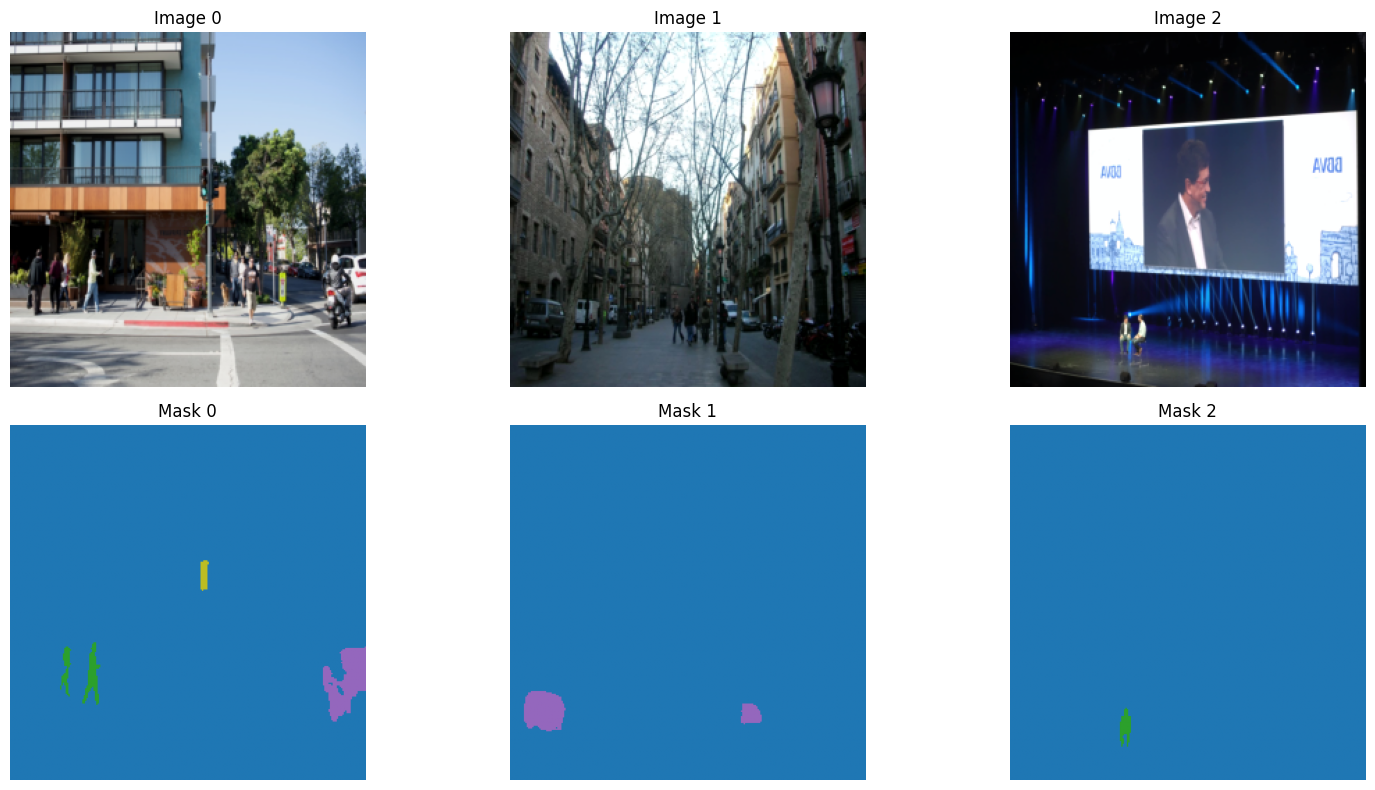

In [ ]:
# check one batch
imgs, masks = next(iter(train_loader))
print(f"image batch: {imgs.shape}")  # [B, 3, 256, 256]
print(f"mask batch: {masks.shape}")   # [B, 256, 256]
print(f"mask vals: {torch.unique(masks)}")

# visualize a few samples
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i in range(3):
    # denormalize for display
    img = imgs[i].permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Image {i}")
    axes[0, i].axis('off')

    axes[1, i].imshow(masks[i].numpy(), cmap='tab10', vmin=0, vmax=5)
    axes[1, i].set_title(f"Mask {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# some comments:
# works correctly
# image batch shape 16 images, 3 channels (RGB), 256x256
# mask batch shape 16 masks, 256x256
# all 6 classes present
# proper alignment in visualisations
# some thing to notice and take into account for later: clearly the annotations are not fully reliable.
# In some pictures some defined classes are clearly present in the image but not annotated (no instance masks)

### U-Net Model

U-Net architecture:
```
Input Image (256×256×3)
        ↓
   [ENCODER: ResNet34 - pretrained on ImageNet]
        ↓ extracts features at decreasing resolutions
   H/2 → H/4 → H/8 → H/16 → H/32
        ↓
   [DECODER: Custom - built in this notebook]
        ↑ upsamples back with skip connections
   H/32 → H/16 → H/8 → H/4 → H/2 → H
        ↓
Output Mask (256×256×6 classes)
```
- **Encoder:** ResNet34 (21M params, 5 stages, pretrained on ImageNet).

It is pre-trained on ImageNet (1.2M images, 1000 classes), so it already knows how to extract useful features like edges, textures, shapes. Those features are reused instead of learning from scratch.

| Stage | Output Channels | Resolution |
|-------|----------------|------------|
| encoder0 | 64 | H/2 |
| pool0 | 64 | H/4 |
| encoder1 (layer1) | 64 | H/4 |
| encoder2 (layer2) | 128 | H/8 |
| encoder3 (layer3) | 256 | H/16 |
| encoder4 (layer4) | 512 | H/32 |

Note on the encoder choice: ResNet34 offers a balance between capacity and efficiency. Deeper encoders (ResNet50/101) offer marginal gains but significantly increase compute cost. Lighter encoders (ResNet18) may underfit on multi-class segmentation. Reference for encoder comparison: https://smp.readthedocs.io/en/latest/encoders.html.

- **Decoder:** Custom upsampling blocks with skip connections
Each decoder block:

1. Upsample — double spatial resolution (transposed convolution)
2. Concatenate — combine with encoder features at same resolution (skip connection)
3. Conv + BatchNorm + ReLU — process combined features
4. Conv + BatchNorm + ReLU — refine further

- **Output:** 6-class pixel-wise prediction

| Stage | Input | Skip From | Output |
|-------|-------|-----------|--------|
| decoder4 | 512 ch, H/32 | encoder3 (256 ch) | 256 ch, H/16 |
| decoder3 | 256 ch, H/16 | encoder2 (128 ch) | 128 ch, H/8 |
| decoder2 | 128 ch, H/8 | encoder1 (64 ch) | 64 ch, H/4 |
| decoder1 | 64 ch, H/4 | encoder0 (64 ch) | 64 ch, H/2 |
| final_upsample | 64 ch, H/2 | — | 32 ch, H |
| final_conv | 32 ch | — | 6 ch (classes) |

Skip connections concatenate encoder features with decoder features at each resolution level, preserving spatial detail lost during downsampling.

#### Design justification
**Pretrained encoder** saves training time, better features than random init; **skip connections** preserves spatial detail lost during downsampling; each encoder level has a corresponding decoder level (**symmetric structure**);
**1×1 final conv** is an efficient way to map features to class predictions (no spatial mixing needed)

In [ ]:
class DecoderBlock(nn.Module):
    # upsampling block: upsample + concat skip + conv + conv
    def __init__(self, in_channels, skip_channels, out_channels, dropout=0.1):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_channels, in_channels, kernel_size=2, stride=2)
        self.conv1 = nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(p=dropout)

    def forward(self, x, skip):
        x = self.upsample(x)
        x = torch.cat([x, skip], dim=1)  # concat along channel dim
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x) # dropout after 1st conv block
        x = self.relu(self.bn2(self.conv2(x)))
        return x


class UNetResNet34(nn.Module):
    #U-Net with ResNet34 encoder
    def __init__(self, num_classes=6, pretrained=True):
        super().__init__()

        # load pretrained ResNet34
        resnet = models.resnet34(weights='IMAGENET1K_V1' if pretrained else None)

        # encoder layers (extract feature maps @ different resolutions)
        self.encoder0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu) # 64, H/2
        self.pool0 = resnet.maxpool # 64, H/4
        self.encoder1 = resnet.layer1  # 64, H/4
        self.encoder2 = resnet.layer2  # 128, H/8
        self.encoder3 = resnet.layer3  # 256, H/16
        self.encoder4 = resnet.layer4  # 512, H/32

        # decoder blocks (upsample back to original resolution)
        self.decoder4 = DecoderBlock(512, 256, 256) # H/32 -> H/16
        self.decoder3 = DecoderBlock(256, 128, 128) # H/16 -> H/8
        self.decoder2 = DecoderBlock(128, 64, 64) # H/8 -> H/4
        self.decoder1 = DecoderBlock(64, 64, 64) # H/4 -> H/2

        # final upsampling and classification
        self.final_upsample = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)  # H/2 -> H
        self.final_conv = nn.Conv2d(32, num_classes, kernel_size=1) # 1x1 conv for classification

    def forward(self, x):
        # encoder (downsampling path)
        e0 = self.encoder0(x)   # [B, 64, H/2, W/2]
        p0 = self.pool0(e0)     # [B, 64, H/4, W/4]
        e1 = self.encoder1(p0)  # [B, 64, H/4, W/4]
        e2 = self.encoder2(e1)  # [B, 128, H/8, W/8]
        e3 = self.encoder3(e2)  # [B, 256, H/16, W/16]
        e4 = self.encoder4(e3)  # [B, 512, H/32, W/32]

        # decoder (upsampling path with skip connections)
        d4 = self.decoder4(e4, e3)  # [B, 256, H/16, W/16]
        d3 = self.decoder3(d4, e2)  # [B, 128, H/8, W/8]
        d2 = self.decoder2(d3, e1)  # [B, 64, H/4, W/4]
        d1 = self.decoder1(d2, e0)  # [B, 64, H/2, W/2]

        # final output
        out = self.final_upsample(d1)  # [B, 32, H, W]
        out = self.final_conv(out)     # [B, num_classes, H, W]

        return out

In [ ]:
# verify
NUM_CLASSES = 6

set_seed()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNetResNet34(num_classes=NUM_CLASSES, pretrained=True).to(device)

# test forward pass
with torch.no_grad():
    dummy = torch.randn(2, 3, 256, 256).to(device)
    out = model(dummy)
    print(f"in: {dummy.shape}")
    print(f"out: {out.shape}")

# param counts
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"total params: {total_params:,}")
print(f"trainable params: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 256MB/s]


in: torch.Size([2, 3, 256, 256])
out: torch.Size([2, 6, 256, 256])
total params: 25,896,934
trainable params: 25,896,934


### Loss Function

Combined loss to handle class imbalance:

#### Class Weights (derived from data itself)
Weights computed from pixel frequencies in the training set using inverse frequency weighting:

$$w_c = \frac{1}{f_c}$$

where $f_c$ is the fraction of pixels belonging to class $c$. Weights are normalized so their mean equals 1. This ensures rare classes (e.g., Traffic light) receive higher weight during training, penalizing misclassification more heavily.

#### Loss Components

**1. Weighted Cross-Entropy Loss**
- Standard pixel-wise classification loss
- Applies class weights to handle imbalance

**2. Dice Loss**
- Measures overlap between prediction and ground truth: $1 - \frac{2|P \cap G|}{|P| + |G|}$
- Less sensitive to class imbalance than CE alone
- Directly optimizes for segmentation quality

**Combined Loss:**
$$\mathcal{L} = \mathcal{L}_{CE} + \mathcal{L}_{Dice}$$

Cross-entropy provides stable gradients and Dice improves boundary quality.

**Reference/source:** [Sudre et al., 2017 — Generalised Dice Overlap as a Deep Learning Loss Function for Highly Unbalanced Segmentations](https://arxiv.org/abs/1707.03237)

In [ ]:
CLASS_NAMES = ["Background", "Person", "Car", "Bus", "Traffic light", "Skyscraper"]
def compute_class_weights(train_ids, masks_dir, num_classes=6):
    pixel_counts = np.zeros(num_classes) # count pixels per class across training set to compute weights

    for img_id in tqdm(train_ids, desc="computing class weights"):
        mask = np.array(Image.open(os.path.join(masks_dir, f"{img_id}.png")))
        # count all classes at once with bincount
        counts = np.bincount(mask.flatten(), minlength=num_classes)
        pixel_counts += counts

    # inverse frequency weighting (higher weight for rare classes)
    total = pixel_counts.sum()
    frequencies = pixel_counts / total
    weights = 1.0 / (frequencies + 1e-6) # avoid division by zero
    weights = weights / weights.sum() * num_classes # normalize to mean=1

    return torch.FloatTensor(weights), pixel_counts, frequencies

class_weights, pixel_counts, frequencies = compute_class_weights(train_ids, DENSE_MASKS_DIR, NUM_CLASSES)

print(f"{'class':<15} {'pixels':>14} {'freq':>10} {'weight':>8}")
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<15} {int(pixel_counts[i]):>14,} {frequencies[i]:>10.4f} {class_weights[i]:>8.3f}")

computing class weights:   1%|          | 14/2772 [00:04<15:09,  3.03it/s]


KeyboardInterrupt: 

In [ ]:
# computation might take a while, so when re-running code - run this cell instead of the one above
# NOTE: after initial training the weights were updated to assign person's class a bit of a higher weight to account things, such as
# varied poses
# partial occlusion (people overlapping with each other)
# class imbalance (person had fewest pixels in training despite high weight)
# labels noisy, as many people not labeled in OpenImages ground truth (issue with all classes actually)

class_weights = torch.FloatTensor([0.040, 2.019, 0.813, 0.761, 1.271, 1.096]) # initially, after data-based weight assignment
class_weights[1] *= 1.5  # let person get 50% more weight
class_weights = class_weights / class_weights.mean()  # renormalize

In [ ]:
class_weights

tensor([0.0342, 2.5923, 0.6959, 0.6514, 1.0880, 0.9382])

In [ ]:
# soft Dice Loss for multi-class segmentation
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        num_classes = logits.shape[1]
        probs = F.softmax(logits, dim=1)

        # one-hot encode targets: [B, H, W] -> [B, C, H, W]
        targets_onehot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

        # dice per class, averaged
        dims = (0, 2, 3) # sum over batch, height, width
        intersection = (probs * targets_onehot).sum(dims)
        cardinality = probs.sum(dims) + targets_onehot.sum(dims)

        dice = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return 1.0 - dice.mean()


class CombinedLoss(nn.Module):
    # weighted CE + Dice Loss
    def __init__(self, class_weights, ce_weight=1.0, dice_weight=1.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.dice = DiceLoss()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        return self.ce_weight * self.ce(logits, targets) + self.dice_weight * self.dice(logits, targets)


criterion = CombinedLoss(class_weights.to(device))

In [ ]:
# test
with torch.no_grad():
    dummy_logits = torch.randn(2, 6, 256, 256).to(device)
    dummy_targets = torch.randint(0, 6, (2, 256, 256)).to(device)
    loss = criterion(dummy_logits, dummy_targets)
    print(f"test loss: {loss.item():.4f}")

test loss: 3.0140


### Training

**Strategy:**
1. Freeze encoder initially — train only the decoder to learn segmentation from pre-trained features
2. Unfreeze and fine-tune — lower learning rate for encoder, higher for decoder

**Optimizer:** AdamW with weight decay for regularization

**Scheduler:** ReduceLROnPlateau — reduce learning rate when validation loss plateaus

**Checkpointing:** Save best model based on validation loss

More extensive explanation:
## Training Loop

### Components

**1. `train_one_epoch`** — Single epoch of training
- `model.train()` — enables training mode (activates dropout, batch norm updates)
- For each batch:
  - `optimizer.zero_grad()` — clear gradients from previous batch (PyTorch accumulates by default)
  - `outputs = model(imgs)` — forward pass: image → prediction
  - `loss = criterion(outputs, masks)` — compute how wrong predictions are
  - `loss.backward()` — backpropagation: compute gradients
  - `optimizer.step()` — update weights using gradients
- Returns average loss across all batches

**2. `validate`** — Evaluation without training
- `@torch.no_grad()` — disables gradient computation (saves memory, faster)
- `model.eval()` — evaluation mode (disables dropout, freezes batch norm)
- Same forward pass, but no backward pass or weight updates
- Returns average validation loss

**3. `EarlyStopping`** — Prevents overfitting by stopping when validation loss stops improving
- `patience` — how many epochs to wait before stopping
- `min_delta` — minimum improvement to count as "better"
- If no improvement for `patience` epochs → stop training
- Example: patience=5 means "if val_loss doesn't improve for 5 epochs, stop"

**4. `train`** — Main training loop
- Runs for `epochs` iterations (or until early stopping)
- Each epoch: train → validate → log → checkpoint
- **Scheduler:** reduces learning rate when validation plateaus (helps escape local minima)
- **Checkpointing:** saves model only when validation loss improves (keeps best model)
- **Early stopping:** breaks loop if no improvement for `patience` epochs
- Returns training history and best validation loss

### Training Flow
```
For each epoch:
    1. Train on all batches → train_loss
    2. Validate on all batches → val_loss
    3. Scheduler adjusts learning rate if needed
    4. If val_loss improved → save checkpoint
    5. If no improvement for patience epochs → stop
```

In [ ]:
# freeze encoder
# approach:
# train decoder first with frozen encoder (1st phase) -> unfreeze and fine-tune with a lower learning rate (2nd phase of training)

def freeze_encoder(model):
    for name, param in model.named_parameters():
        if 'encoder' in name:
            param.requires_grad = False

def unfreeze_encoder(model):
    for name, param in model.named_parameters():
        if 'encoder' in name:
            param.requires_grad = True

freeze_encoder(model)

In [ ]:
# training config
EPOCHS_FROZEN = 10 # epochs with frozen encoder
EPOCHS_FINETUNE = 10 # epochs with full fine-tuning
LR_DECODER = 1e-3 # learning rate for decoder
LR_ENCODER = 5e-6 # LR for encoder (when unfrozen)

CHECKPOINT_DIR = "/content/drive/MyDrive/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# optimizer
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_DECODER,
    weight_decay=1e-4
)

# scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for imgs, masks in tqdm(loader, desc="Training", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    for imgs, masks in tqdm(loader, desc="validation", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        total_loss += loss.item()

    return total_loss / len(loader)

class EarlyStopping:
  def __init__(self, patience=5, min_delta=0.001):
    self.patience = patience
    self.min_delta = min_delta
    self.counter = 0
    self.best_loss = float('inf')
    self.early_stop = False

  def __call__(self, val_loss):
    if val_loss < self.best_loss - self.min_delta:
      self.best_loss = val_loss
      self.counter = 0
    else:
      self.counter += 1
      if self.counter >= self.patience:
        self.early_stop = True
    return self.early_stop


# training loop with validation and checkpointing
def train(model, train_loader, val_loader, criterion, optimizer, scheduler,
          epochs, device, checkpoint_path, best_val_loss=float('inf'), patience=5):

    history = {'train_loss': [], 'val_loss': []}
    early_stopping = EarlyStopping(patience=patience, min_delta=0.001)

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = validate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        # scheduler step
        scheduler.step(val_loss)

        #checkpointing
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
            }, checkpoint_path)
            print(f"epoch {epoch+1}/{epochs} — train: {train_loss:.4f}, val: {val_loss:.4f} — saved")
        else:
            print(f"epoch {epoch+1}/{epochs} — train: {train_loss:.4f}, val: {val_loss:.4f}")

        # early stopping
        if early_stopping(val_loss):
            print(f"early stopping at epoch {epoch+1}")
            break

    return history, best_val_loss

In [ ]:
# initially -> train with frozen encoder
set_seed()
history1, best_val_loss = train(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    epochs=EPOCHS_FROZEN,
    device=device,
    checkpoint_path=os.path.join(CHECKPOINT_DIR, "best_model_v2.pt")
)

epoch 1/10 — train: 1.8987, val: 1.4970 — saved


epoch 2/10 — train: 1.4868, val: 1.3260 — saved


epoch 3/10 — train: 1.2543, val: 1.1857 — saved


epoch 4/10 — train: 1.1792, val: 1.1765 — saved


epoch 5/10 — train: 1.1094, val: 1.1980


epoch 6/10 — train: 1.0727, val: 1.1158 — saved


epoch 7/10 — train: 1.0140, val: 1.1188


epoch 8/10 — train: 1.0198, val: 1.1106 — saved


epoch 9/10 — train: 0.9956, val: 1.0259 — saved


epoch 10/10 — train: 0.9969, val: 1.0499


In [ ]:
# second phase: fine-tune entire model
set_seed()

unfreeze_encoder(model)

# new optimizer with different LR for encoder vs decoder
optimizer = torch.optim.AdamW([
    {'params': [p for n, p in model.named_parameters() if 'encoder' in n], 'lr': LR_ENCODER},
    {'params': [p for n, p in model.named_parameters() if 'encoder' not in n], 'lr': LR_DECODER * 0.1},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

history2, best_val_loss = train(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    epochs=EPOCHS_FINETUNE,
    device=device,
    checkpoint_path=os.path.join(CHECKPOINT_DIR, "best_model_v2.pt"),
    best_val_loss=best_val_loss
)

epoch 1/10 — train: 0.8712, val: 0.9794 — saved


epoch 2/10 — train: 0.8537, val: 0.9830


epoch 3/10 — train: 0.7927, val: 0.9577 — saved


epoch 4/10 — train: 0.7760, val: 0.9418 — saved


epoch 5/10 — train: 0.7430, val: 0.9680


epoch 6/10 — train: 0.7242, val: 0.9814


epoch 7/10 — train: 0.6816, val: 0.9674


epoch 8/10 — train: 0.6869, val: 0.9938


epoch 9/10 — train: 0.6760, val: 0.9787
early stopping at epoch 9


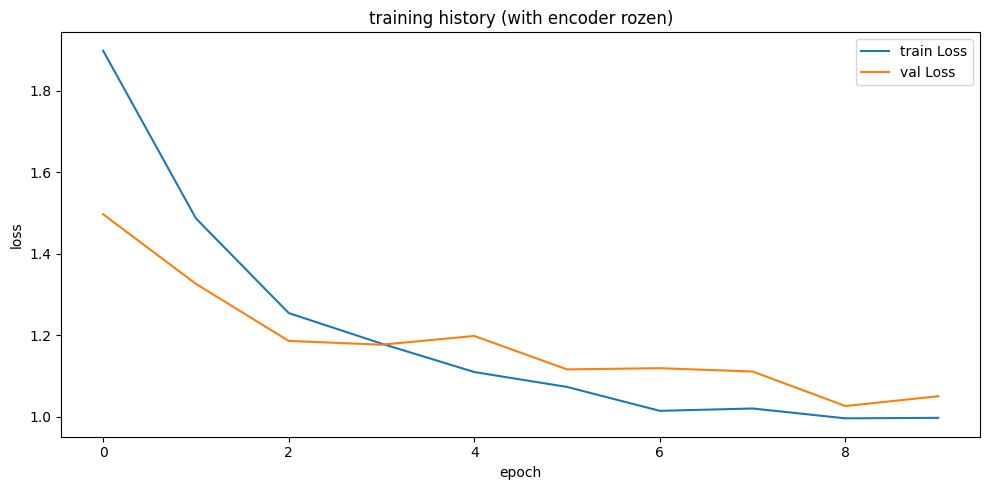

In [ ]:
# see training history
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history1['train_loss'], label='train Loss')
ax.plot(history1['val_loss'], label='val Loss')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_title('training history (with encoder rozen)')
ax.legend()
plt.tight_layout()
plt.show()

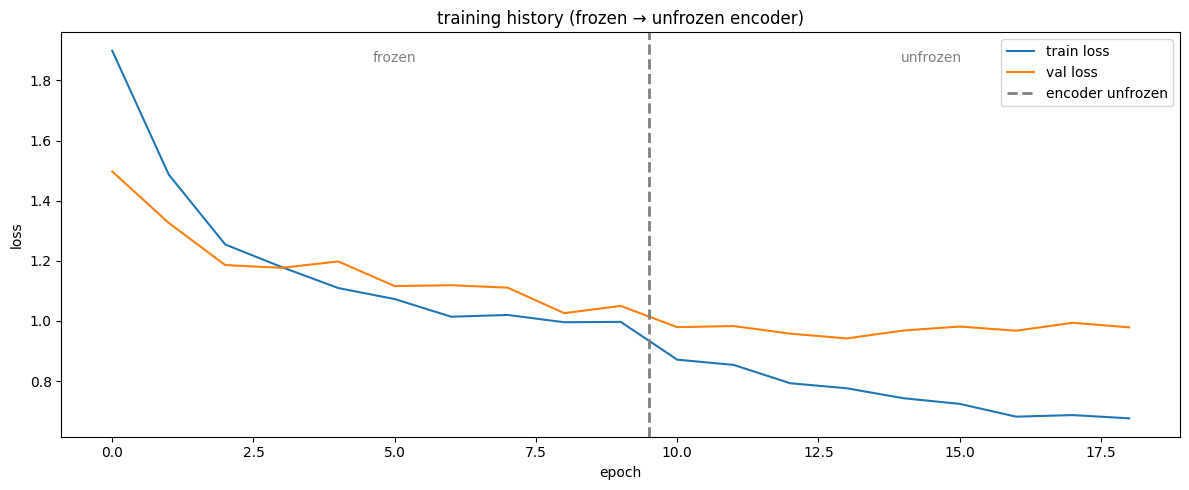

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

all_train = history1['train_loss'] + history2['train_loss']
all_val = history1['val_loss'] + history2['val_loss']

ax.plot(all_train, label='train loss')
ax.plot(all_val, label='val loss')

# line at transition point
transition = len(history1['train_loss']) - 0.5
ax.axvline(x=transition, color='gray', linestyle='--', linewidth=2, label='encoder unfrozen')

ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_title('training history (frozen → unfrozen encoder)')
ax.legend()

frozen_mid = len(history1['train_loss']) / 2
unfrozen_mid = len(history1['train_loss']) + len(history2['train_loss']) / 2
y_pos = ax.get_ylim()[1] * 0.95

ax.text(frozen_mid, y_pos, 'frozen', ha='center', color='gray')
ax.text(unfrozen_mid, y_pos, 'unfrozen', ha='center', color='gray')

plt.tight_layout()
plt.show()

In [ ]:
# best checkpoint
checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, "best_model_v2.pt"))
model.load_state_dict(checkpoint['model_state_dict'])
print(f"best model from epoch {checkpoint['epoch']+1} with val loss {checkpoint['val_loss']:.4f}")

best model from epoch 4 with val loss 0.9418


## Evaluation

Metrics computed on the test set (100 held-out images):
- **Pixel Accuracy:** % of correctly classified pixels
- **Precision:** TP / (TP + FP) — how many predicted pixels are correct
- **Recall:** TP / (TP + FN) — how many actual pixels were found
- **F1 Score:** Harmonic mean of precision and recall
- **IoU (Intersection over Union):** Standard segmentation metric

All metrics computed per-class and averaged (macro).

In [ ]:
@torch.no_grad()
def evaluate(model, loader, device, num_classes=6):
    # compute segmentation metrics on a dataset
    model.eval()

    # confusion matrix: [num_classes, num_classes]
    # conf[i, j] = pixels with true class i predicted as class j
    conf_matrix = torch.zeros(num_classes, num_classes, dtype=torch.long)

    for imgs, masks in tqdm(loader, desc="Evaluating"):
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)  # [B, H, W]

        # update confusion matrix
        for t, p in zip(masks.view(-1).cpu(), preds.view(-1).cpu()):
            conf_matrix[t, p] += 1

    return conf_matrix


def compute_metrics(conf_matrix, class_names):
    #compute per-class and overall metrics from confusion matrix
    num_classes = conf_matrix.shape[0]

    # per-class metrics
    metrics = {}

    for c in range(num_classes):
        tp = conf_matrix[c, c].item()
        fp = conf_matrix[:, c].sum().item() - tp
        fn = conf_matrix[c, :].sum().item() - tp

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        iou = tp / (tp + fp + fn + 1e-8)

        metrics[class_names[c]] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'iou': iou,
        }

    # overall pixel accuracy
    pixel_acc = conf_matrix.diag().sum().item() / conf_matrix.sum().item()

    # macro averages (excluding bg)
    classes_no_bg = class_names[1:]  # exclude background
    macro_precision = np.mean([metrics[c]['precision'] for c in classes_no_bg])
    macro_recall = np.mean([metrics[c]['recall'] for c in classes_no_bg])
    macro_f1 = np.mean([metrics[c]['f1'] for c in classes_no_bg])
    macro_iou = np.mean([metrics[c]['iou'] for c in classes_no_bg])

    return metrics, pixel_acc, macro_precision, macro_recall, macro_f1, macro_iou

In [ ]:
# eval on test set
conf_matrix = evaluate(model, test_loader, device, NUM_CLASSES)
metrics, pixel_acc, macro_prec, macro_rec, macro_f1, macro_iou = compute_metrics(conf_matrix, CLASS_NAMES)

# results
print(f"\npixel accuracy: {pixel_acc:.4f}")
print(f"\nper-class metrics:")
print(f"{'class':<15} {'precision':>10} {'recall':>10} {'F1':>10} {'IoU':>10}")
print("-" * 55)
for name in CLASS_NAMES:
    m = metrics[name]
    print(f"{name:<15} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1']:>10.4f} {m['iou']:>10.4f}")

print("-" * 55)
print(f"{'Macro (no bg)':<15} {macro_prec:>10.4f} {macro_rec:>10.4f} {macro_f1:>10.4f} {macro_iou:>10.4f}")

Evaluating: 100%|██████████| 7/7 [01:54<00:00, 16.39s/it]


pixel accuracy: 0.8110

per-class metrics:
class            precision     recall         F1        IoU
-------------------------------------------------------
Background          0.9879     0.7870     0.8761     0.7795
Person              0.2538     0.8591     0.3918     0.2436
Car                 0.5136     0.9080     0.6561     0.4882
Bus                 0.7173     0.9418     0.8144     0.6869
Traffic light       0.4435     0.9270     0.6000     0.4286
Skyscraper          0.3178     0.9405     0.4750     0.3115
-------------------------------------------------------
Macro (no bg)       0.4492     0.9153     0.5875     0.4318


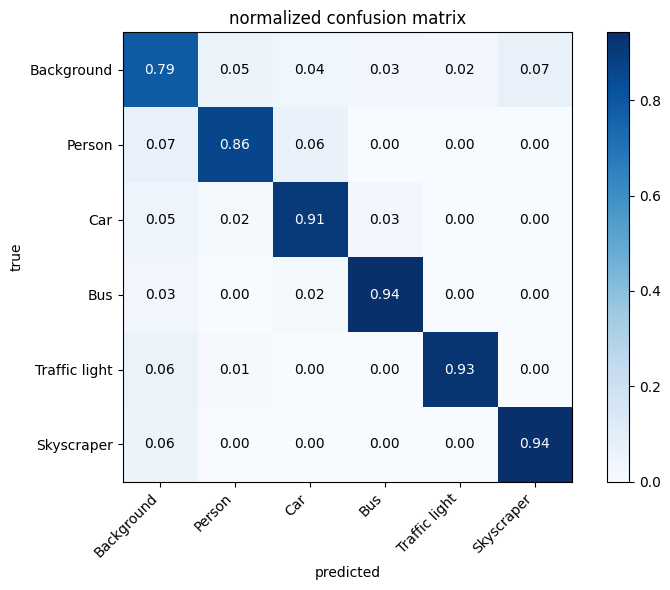

In [ ]:
# confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
conf_normalized = conf_matrix.float() / conf_matrix.sum(dim=1, keepdim=True)

im = ax.imshow(conf_normalized, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('normalized confusion matrix')

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        val = conf_normalized[i, j].item()
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color='white' if val > 0.5 else 'black')

plt.colorbar(im)
plt.tight_layout()
plt.show()

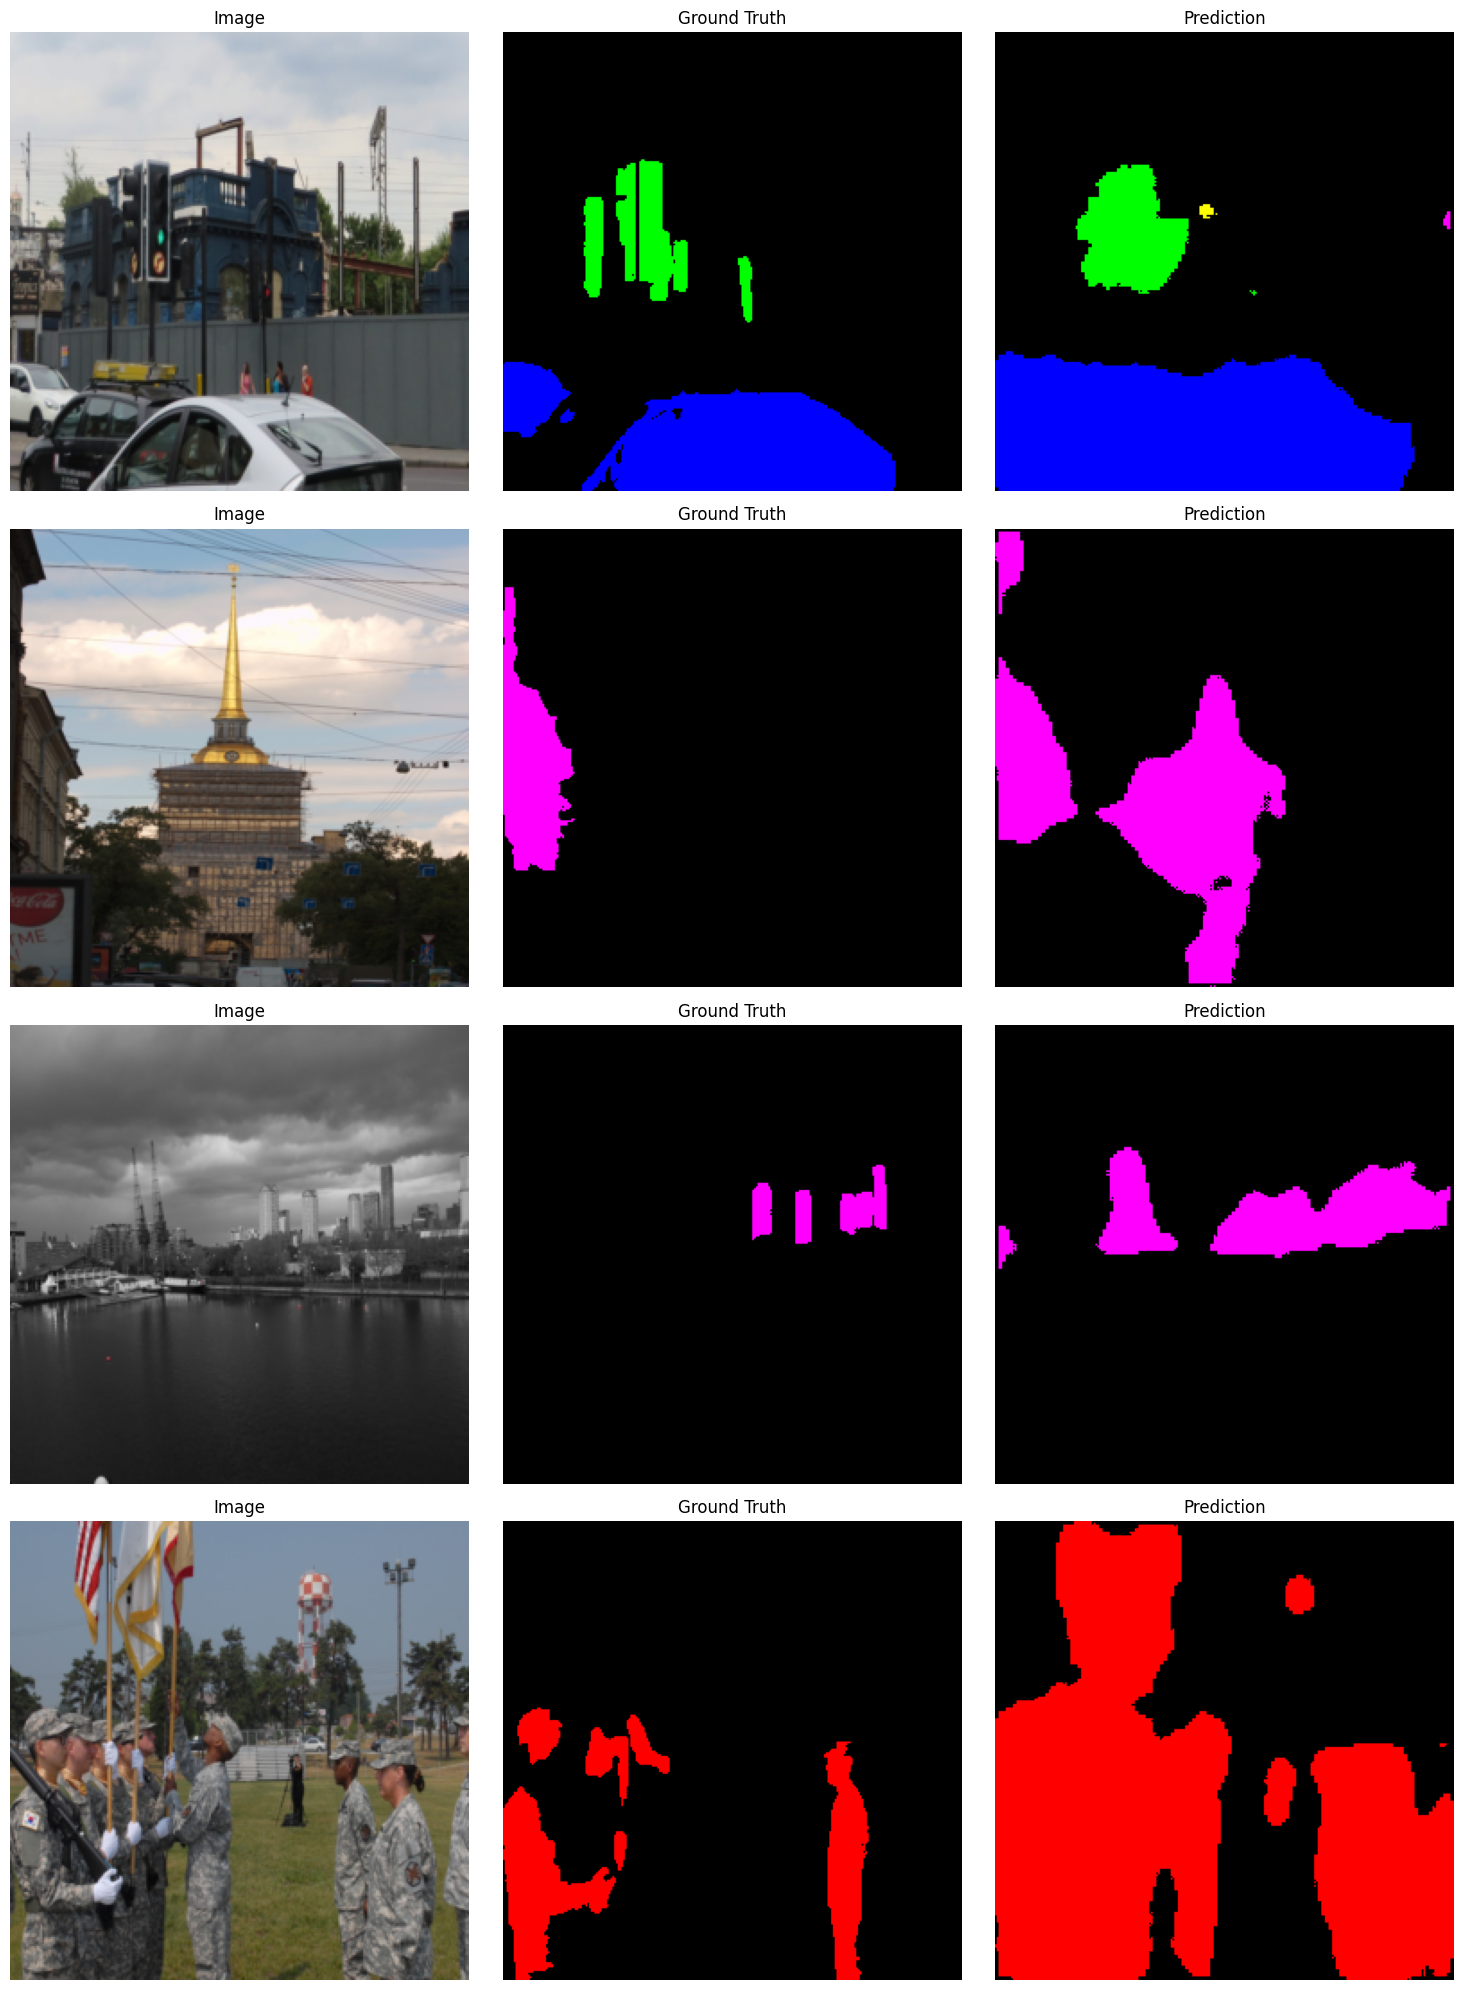

In [ ]:
# predictions on test set visually
@torch.no_grad()
def visualize_predictions(model, dataset, device, n=4, indices=None):
    model.eval()

    if indices is None:
        indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(n, 3, figsize=(15, 5*n))

    colors = np.array([
        [0, 0, 0], # background
        [255, 0, 0], # person
        [0, 0, 255], # car
        [255, 255, 0], # bus
        [0, 255, 0], # traffic light
        [255, 0, 255], # skyscraper
    ]) / 255.0

    for row, idx in enumerate(indices):
        img, mask = dataset[idx]
        img_input = img.unsqueeze(0).to(device)
        pred = model(img_input).argmax(dim=1).squeeze().cpu().numpy()

        # denormalize image
        img_np = img.permute(1, 2, 0).numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)

        # colour masks
        mask_np = mask.numpy()
        mask_color = colors[mask_np]
        pred_color = colors[pred]

        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title("Image")
        axes[row, 0].axis('off')

        axes[row, 1].imshow(mask_color)
        axes[row, 1].set_title("Ground Truth")
        axes[row, 1].axis('off')

        axes[row, 2].imshow(pred_color)
        axes[row, 2].set_title("Prediction")
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_dataset, device, n=4)

100%|██████████| 100/100 [00:03<00:00, 27.36it/s]


hardest cases (highest loss):
  Index 21: loss = 3.3597
  Index 18: loss = 2.7293
  Index 77: loss = 2.6421
  Index 42: loss = 2.5029
  Index 19: loss = 2.2067
  Index 39: loss = 2.0326
  Index 38: loss = 1.9998
  Index 31: loss = 1.9397
  Index 85: loss = 1.8456
  Index 26: loss = 1.8292


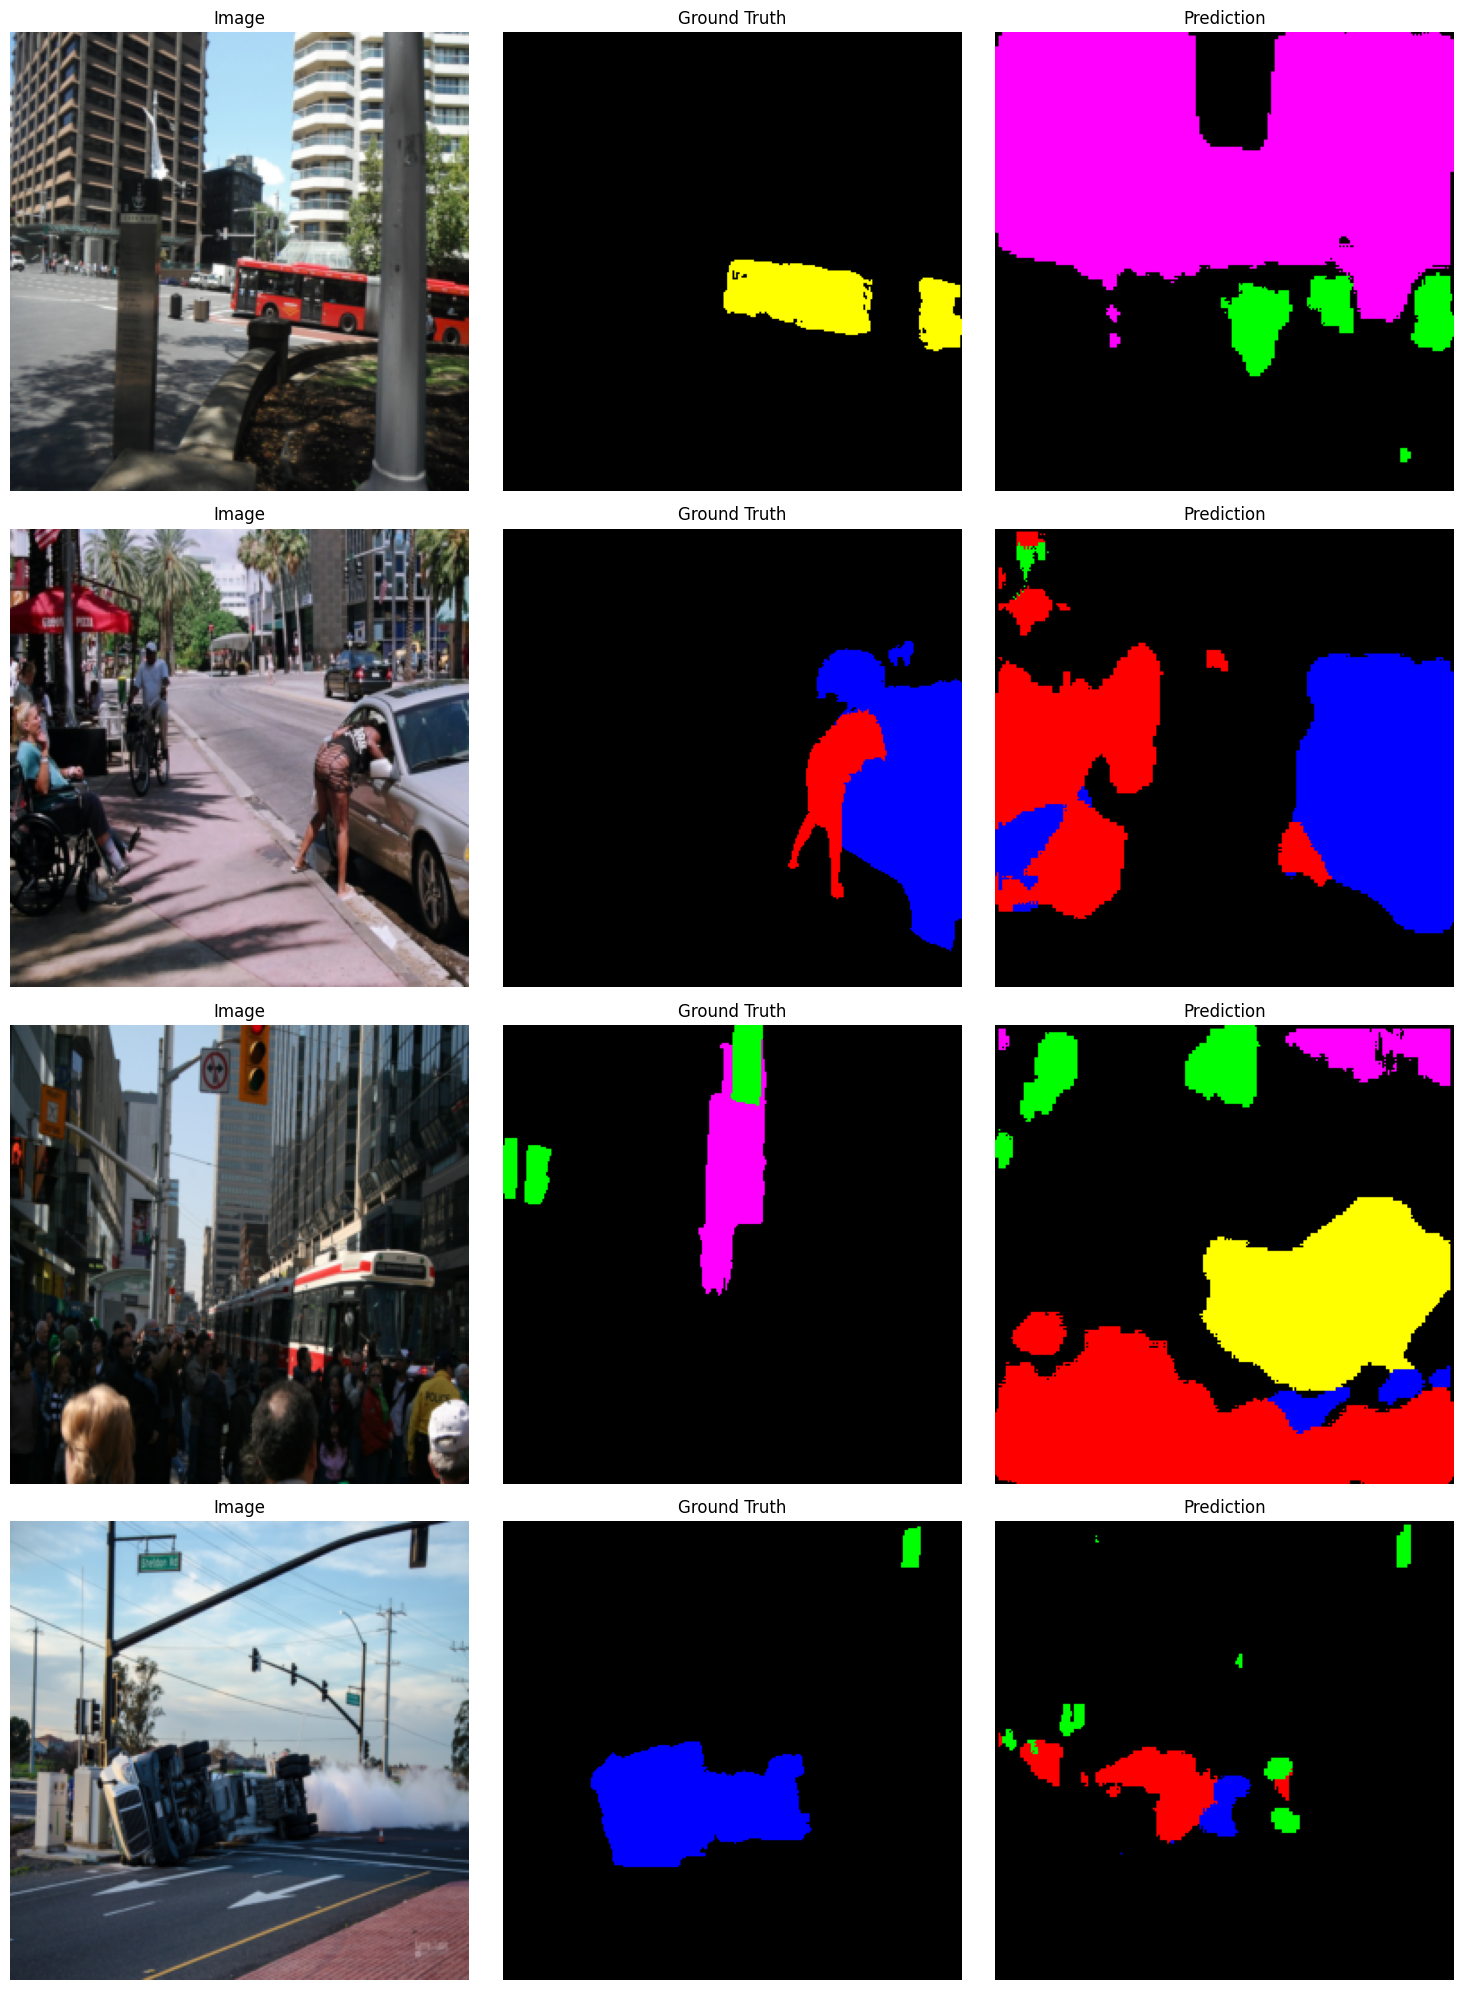

In [ ]:
# analysis of hardest cases / errors
@torch.no_grad()
def find_hardest_cases(model, dataset, criterion, device, n=10):
    model.eval()
    losses = []

    for idx in tqdm(range(len(dataset))):
        img, mask = dataset[idx]
        img = img.unsqueeze(0).to(device)
        mask = mask.unsqueeze(0).to(device)

        output = model(img)
        loss = criterion(output, mask).item()
        losses.append((idx, loss))

    losses.sort(key=lambda x: x[1], reverse=True)

    return losses[:n]


# usage
hardest = find_hardest_cases(model, test_dataset, criterion, device, n=10)
print("hardest cases (highest loss):")
for idx, loss in hardest:
    print(f"  Index {idx}: loss = {loss:.4f}")

# visualize them
hardest_indices = [idx for idx, _ in hardest[:4]]
visualize_predictions(model, test_dataset, device, n=4, indices=hardest_indices)

Model achieves 81% pixel accuracy with strong recall (0.91). Lower precision is partially attributable to incomplete annotations in OpenImages — the model correctly segments objects that were not labeled in ground truth

Further analysis of hardest cases (highest loss) confirms this pattern. The model correctly segments objects that are missing from ground truth annotations. In all four cases, the model identifies additional vehicles, people, and buildings that were not labeled. This explains the high loss values. The model is occassionally penalized for correct predictions. Seems like loss-based error analysis can be misleading on partially-annotated datasets

In [ ]:
# save final model and training artifacts
CHECKPOINT_DIR = "/content/drive/MyDrive/checkpoints"

# save best model (already saved during training but also save final state)
torch.save({
    'model_state_dict': model.state_dict(),
    'class_weights': class_weights,
    'history1': history1,
    'history2': history2,
    'metrics': metrics,
    'pixel_acc': pixel_acc,
    'macro_f1': macro_f1,
    'macro_iou': macro_iou,
}, os.path.join(CHECKPOINT_DIR, "model_v2.pt"))

In [ ]:
# load model in a new session
#checkpoint = torch.load(
    #"/content/drive/MyDrive/checkpoints/model_v2.pt",
    #weights_only=False
#)
#model = UNetResNet34(num_classes=6, pretrained=False).to(device)
#model.load_state_dict(checkpoint['model_state_dict'])
#model.eval()

In [ ]:
checkpoint = torch.load(
    "/content/drive/MyDrive/checkpoints/model_v2.pt",
    map_location=torch.device('cpu'),
    weights_only=False
)

In [ ]:
# inference f-ion: run inference on any image
# plug in an image
def predict_single_image(model, image_path, device, img_size=256):
    model.eval()

    # load and preprocess
    img = Image.open(image_path).convert("RGB")
    original_size = img.size  # (W, H)
    img_resized = img.resize((img_size, img_size), Image.BILINEAR)

    # to tensor + normalize
    img_tensor = torch.from_numpy(np.array(img_resized)).permute(2, 0, 1).float() / 255.0
    normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    img_tensor = normalize(img_tensor).unsqueeze(0).to(device)

    # predict
    with torch.no_grad():
        output = model(img_tensor)
        pred = output.argmax(dim=1).squeeze().cpu().numpy()

    # resize prediction back to original size
    pred_resized = np.array(Image.fromarray(pred.astype(np.uint8)).resize(original_size, Image.NEAREST))

    return pred_resized, np.array(img)


# this f-ion: to predict and visually display results (predicted mask) for any image
def viz_prediction(model, image_path, device):
    pred, img = predict_single_image(model, image_path, device)

    colors = np.array([
        [0, 0, 0], # background
        [255, 0, 0], # person
        [0, 0, 255], # car
        [255, 255, 0], # bus
        [0, 255, 0], # traffic light
        [255, 0, 255], # skyscraper
    ])

    pred_color = colors[pred]

    # blend
    alpha = 0.5
    blended = (img * (1 - alpha) + pred_color * alpha).astype(np.uint8)
    blended[pred == 0] = img[pred == 0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title("Input Image")
    axes[0].axis('off')

    axes[1].imshow(pred_color)
    axes[1].set_title("Prediction")
    axes[1].axis('off')

    axes[2].imshow(blended)
    axes[2].set_title("Overlay")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # print class counts
    unique, counts = np.unique(pred, return_counts=True)
    print("Detected classes:")
    for u, c in zip(unique, counts):
        pct = 100 * c / pred.size
        print(f"  {CLASS_NAMES[u]}: {pct:.1f}%")


# Usage:
# viz_prediction(model, "/path/to/any/image.jpg", device)

In [ ]:
# test
device = torch.device('cpu')

model = UNetResNet34(num_classes=6, pretrained=False)

checkpoint = torch.load(
    "/content/drive/MyDrive/checkpoints/best_model_v2.pt",
    map_location=device  # this maps the weights to CPU
)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

UNetResNet34(
  (encoder0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (encoder1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

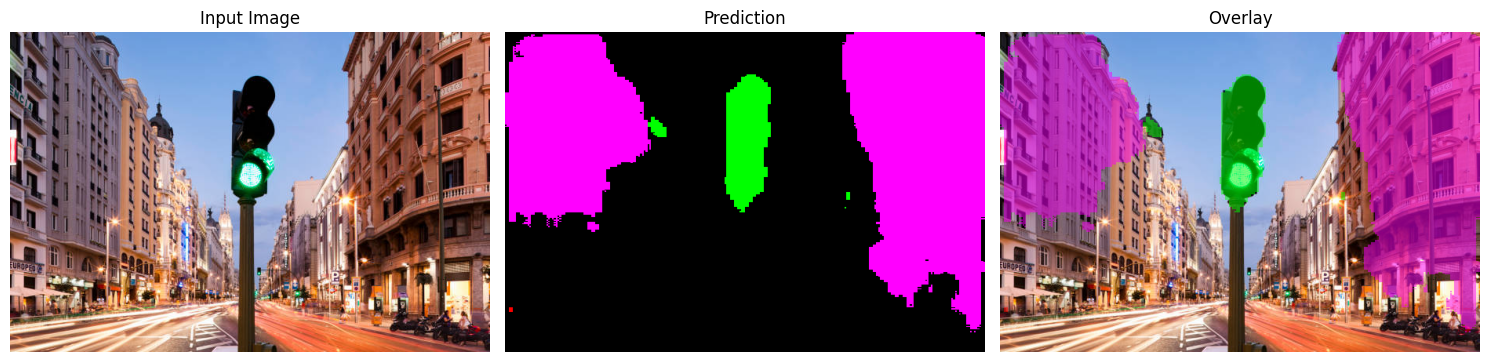

Detected classes:
  Background: 62.4%
  Person: 0.0%
  Traffic light: 3.4%
  Skyscraper: 34.2%


In [ ]:
viz_prediction(model,"/content/test_1.jpg", device)

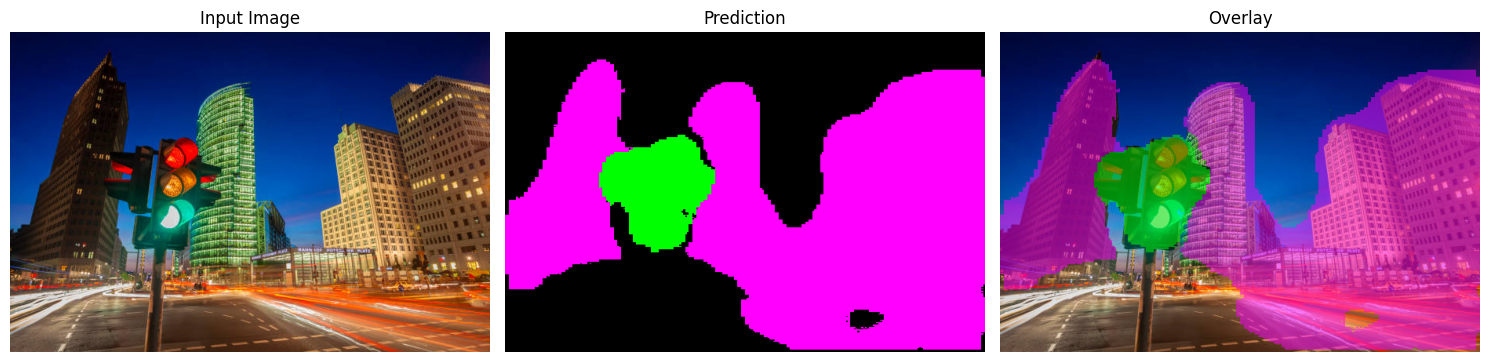

Detected classes:
  Background: 43.3%
  Traffic light: 5.7%
  Skyscraper: 51.0%


In [ ]:
viz_prediction(model,"/content/test_2.jpg", device)

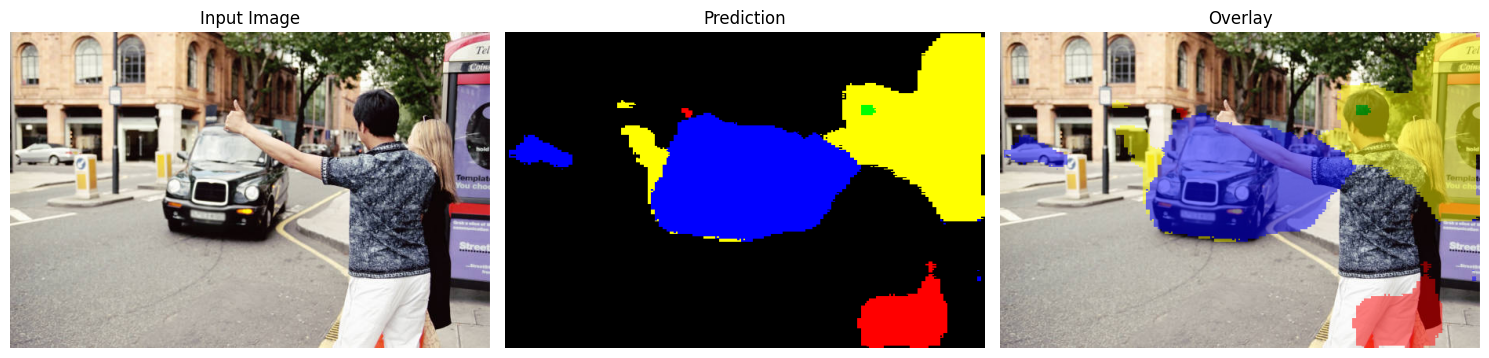

Detected classes:
  Background: 70.6%
  Person: 3.1%
  Car: 13.4%
  Bus: 12.8%
  Traffic light: 0.1%


In [ ]:
viz_prediction(model,"/content/test_3.jpg", device)

why struggling to detect on the last image:
1. person has an unusual pose with arm extended, back to the camera
2. people overlapping (still a thing with partial occlusion)
3. large in frame. Quite likely that the model trained on smaller/distant people.
4. Interestingly confusing some advertisment board with a bus - likely colour is confusing the model

In [ ]:
# for testing - look for most classes represented in some image
# annotations
import pickle
with open("/content/drive/MyDrive/all_annots.pkl", "rb") as f:
    all_annots = pickle.load(f)

# images with most classes
def count_classes(img_id):
    return len(set(a['class_name'] for a in all_annots[img_id]))

image_class_counts = [(img_id, count_classes(img_id)) for img_id in all_annots.keys()]
image_class_counts.sort(key=lambda x: x[1], reverse=True)

print("most classes:")
for img_id, n_classes in image_class_counts[:10]:
    classes = set(a['class_name'] for a in all_annots[img_id])
    print(f"  {img_id}: {n_classes} classes - {classes}")

most classes:
  274a6e8a30ac4b48: 4 classes - {'Bus', 'Person', 'Traffic light', 'Car'}
  b649a680a6b1c0dd: 4 classes - {'Bus', 'Person', 'Traffic light', 'Car'}
  20732af84c278db0: 3 classes - {'Bus', 'Person', 'Car'}
  ab7633a6f88c9ebe: 3 classes - {'Bus', 'Skyscraper', 'Car'}
  821c8bb6858ceaa8: 3 classes - {'Person', 'Skyscraper', 'Car'}
  3962d6a61bc57529: 3 classes - {'Person', 'Skyscraper', 'Car'}
  57f76ac3a63a2f3c: 3 classes - {'Bus', 'Person', 'Car'}
  aa0c2f01e57c0887: 3 classes - {'Bus', 'Skyscraper', 'Car'}
  cb7b60f48691752e: 3 classes - {'Bus', 'Person', 'Car'}
  bfb8cae92bdb2304: 3 classes - {'Bus', 'Person', 'Car'}


In [ ]:
# additional code to also include ground truth
def viz_prediction_with_gt(model, image_path, mask_path, device):
    pred, img = predict_single_image(model, image_path, device)

    gt_mask = np.array(Image.open(mask_path))

    if gt_mask.shape != img.shape[:2]:
        gt_mask = np.array(Image.fromarray(gt_mask).resize((img.shape[1], img.shape[0]), Image.NEAREST))

    colors = np.array([
        [0, 0, 0],
        [255, 0, 0],
        [0, 0, 255],
        [255, 255, 0],
        [0, 255, 0],
        [255, 0, 255],
    ])

    pred_color = colors[pred]
    gt_color = colors[gt_mask]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img)
    axes[0].set_title("Input Image")
    axes[0].axis('off')

    axes[1].imshow(gt_color)
    axes[1].set_title("Ground Truth")
    axes[1].axis('off')

    axes[2].imshow(pred_color)
    axes[2].set_title("Prediction")
    axes[2].axis('off')

    alpha = 0.5
    blended = (img * (1 - alpha) + pred_color * alpha).astype(np.uint8)
    blended[pred == 0] = img[pred == 0]
    axes[3].imshow(blended)
    axes[3].set_title("Overlay")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    print("Ground Truth classes:")
    for u in np.unique(gt_mask):
        print(f"  {CLASS_NAMES[u]}")

    print("\nPredicted classes:")
    for u in np.unique(pred):
        pct = 100 * (pred == u).sum() / pred.size
        print(f"  {CLASS_NAMES[u]}: {pct:.1f}%")

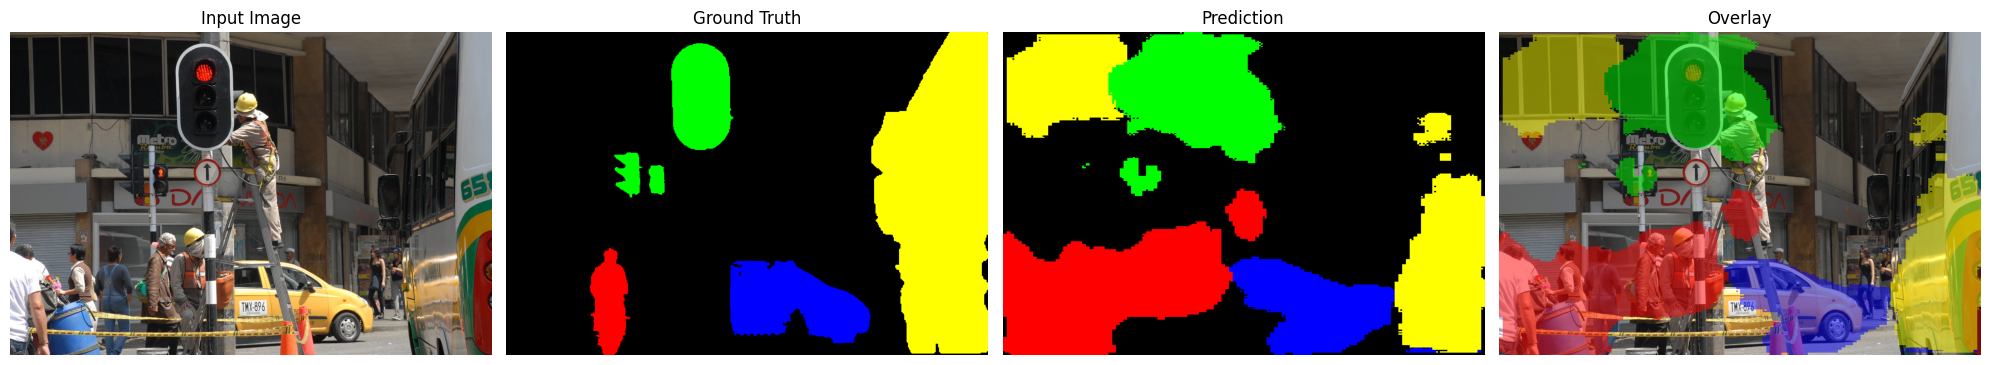

Ground Truth classes:
  Background
  Person
  Car
  Bus
  Traffic light

Predicted classes:
  Background: 53.6%
  Person: 14.4%
  Car: 6.5%
  Bus: 14.9%
  Traffic light: 10.6%


In [ ]:
img_id = "274a6e8a30ac4b48"
viz_prediction_with_gt(
    model,
    f"/content/drive/MyDrive/images/{img_id}.jpg",
    f"/content/drive/MyDrive/dense_masks/{img_id}.png",
    device
)

In [ ]:
# reate random noise image
random_img = np.random.randint(0, 256, (256, 256, 3), dtype=np.uint8)
Image.fromarray(random_img).save("/content/random.jpg")
viz_prediction(model, "/content/random.jpg", device)

In [ ]:
# out on pixel 123, 123 (example)
# first - get prediction
pred, img = predict_single_image(model, "/content/test_1.jpg", device)

# then - check pixel (123, 123)
pixel_class = pred[123, 123]
print(f"pixel (123, 123) class: {pixel_class} = {CLASS_NAMES[pixel_class]}")

pixel (123, 123) class: 5 = Skyscraper


In [ ]:
# present a target - this is a mask
mask = Image.open(f"/content/drive/MyDrive/dense_masks/{img_id}.png")
print(f"shape: {np.array(mask).shape}")
print(f"unique vals: {np.unique(mask)}")

shape: (687, 1024)
unique vals: [0 1 2 3 4]


In [ ]:
# demo classification pipeline on a concrete pixel
import torch.nn.functional as F

# forward pass
img = Image.open(f"/content/drive/MyDrive/dense_masks/{img_id}.png").convert("RGB")
img_resized = img.resize((256, 256))
img_tensor = torch.from_numpy(np.array(img_resized)).permute(2, 0, 1).float() / 255.0
normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
img_tensor = normalize(img_tensor).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(img_tensor)

# extract pixel (123, 123)
pixel_logits = logits[0, :, 123, 123]
print(f"1. Logits (raw): {pixel_logits}")

# softmax to probabilities
pixel_probs = F.softmax(pixel_logits, dim=0)
print(f"2. Probabilities: {pixel_probs}")
print(f"   Sum: {pixel_probs.sum():.4f}")

# argmax for decision
predicted_class = pixel_probs.argmax().item()
confidence = pixel_probs[predicted_class].item()
print(f"3. Decision: Class {predicted_class} ({CLASS_NAMES[predicted_class]}) with {confidence:.1%} confidence")

1. Logits (raw): tensor([ 5.4131,  0.1613, -2.4162, -3.4763, -1.3432,  0.7966])
2. Probabilities: tensor([9.8345e-01, 5.1516e-03, 3.9134e-04, 1.3557e-04, 1.1443e-03, 9.7242e-03])
   Sum: 1.0000
3. Decision: Class 0 (Background) with 98.3% confidence


***Note on the pipeline:*** <br>
Pipeline is: logits → softmax → argmax.
No threshold is needed the highest probability class is being picked

## SAM Benchmark

Comparing our U-Net model against [Segment Anything Model (SAM)](https://segment-anything.com/) by Meta AI.

**Key differences:**
- **Model, created in this notebook:** Trained specifically for 6 urban classes, outputs semantic segmentation directly
- **SAM:** General-purpose segmentation, requires prompts (points/boxes), outputs instance masks without class labels

**Comparison approach:**
Since SAM doesn't output class labels, use SAM in "automatic mask generation" mode and compare:
1. Segmentation quality (visual comparison)
2. Mask coverage and boundary precision
3. Inference speed

Note: This is not a direct apples-to-apples comparison — SAM is designed for different use cases. The goal is to understand trade-offs between task-specific models and foundation models.

In [ ]:
# install SAM (if not installed yet)
!pip install segment-anything
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

In [ ]:
# load
sam_checkpoint = "sam_vit_b_01ec64.pth"
sam = sam_model_registry["vit_b"](checkpoint=sam_checkpoint) # ViT-B for speed, ViT-H is larger/better but slower
sam.to(device)

mask_generator = SamAutomaticMaskGenerator(sam)

In [ ]:
# compare both on test images

def compare_with_sam(model, sam_generator, image_path, device):

    img = np.array(Image.open(image_path).convert("RGB"))

    # my model prediction
    start_time = time.time()
    pred, _ = predict_single_image(model, image_path, device)
    time_t = time.time() - start_time

    # SAM prediction
    start_time = time.time()
    sam_masks = sam_generator.generate(img)
    sam_time = time.time() - start_time

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # original
    axes[0].imshow(img)
    axes[0].set_title("Input Image")
    axes[0].axis('off')

    colors = np.array([
        [0, 0, 0],
        [255, 0, 0],
        [0, 0, 255],
        [255, 255, 0],
        [0, 255, 0],
        [255, 0, 255],
    ])
    colored = colors[pred]
    axes[1].imshow(colored)
    axes[1].set_title(f"urban scene model ({time_t:.2f}s)")
    axes[1].axis('off')

    sam_overlay = np.zeros_like(img)
    sorted_masks = sorted(sam_masks, key=lambda x: x['area'], reverse=True)
    for i, mask_data in enumerate(sorted_masks):
        mask = mask_data['segmentation']
        color = plt.cm.tab20(i % 20)[:3]
        sam_overlay[mask] = [int(c * 255) for c in color]

    axes[2].imshow(sam_overlay)
    axes[2].set_title(f"SAM ({sam_time:.2f}s)\n{len(sam_masks)} masks")
    axes[2].axis('off')

    blended = (img * 0.5 + sam_overlay * 0.5).astype(np.uint8)
    axes[3].imshow(blended)
    axes[3].set_title("SAM Overlay")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    return time_t, sam_time, len(sam_masks)

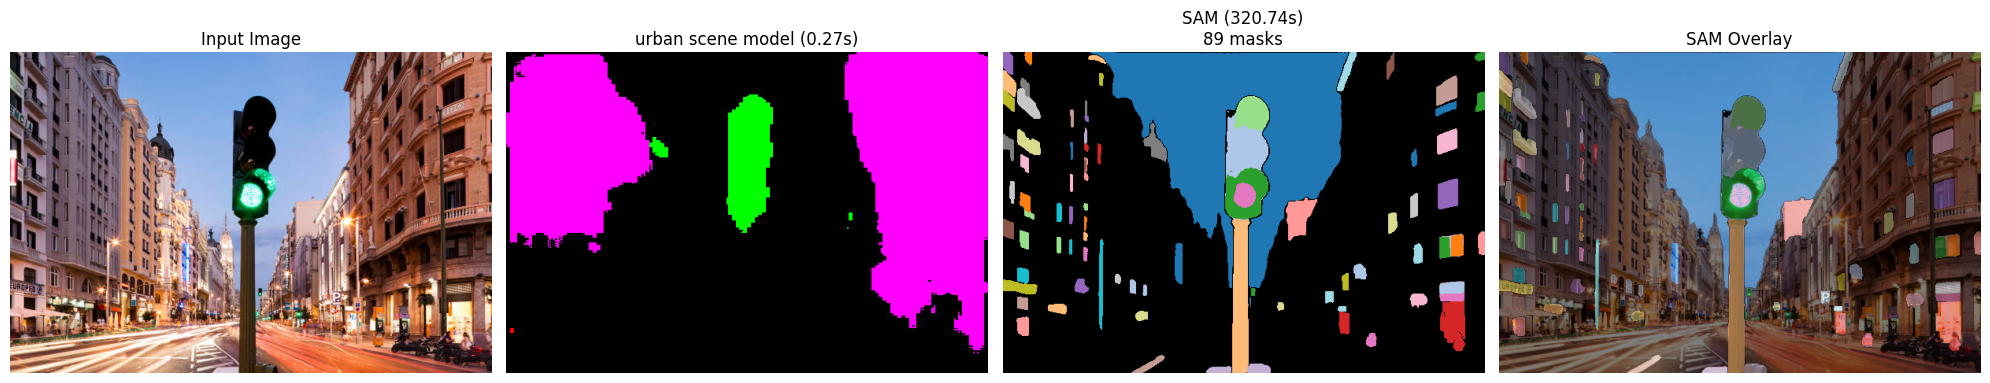

urban scene model: 0.27s | SAM: 320.74s | SAM masks: 89


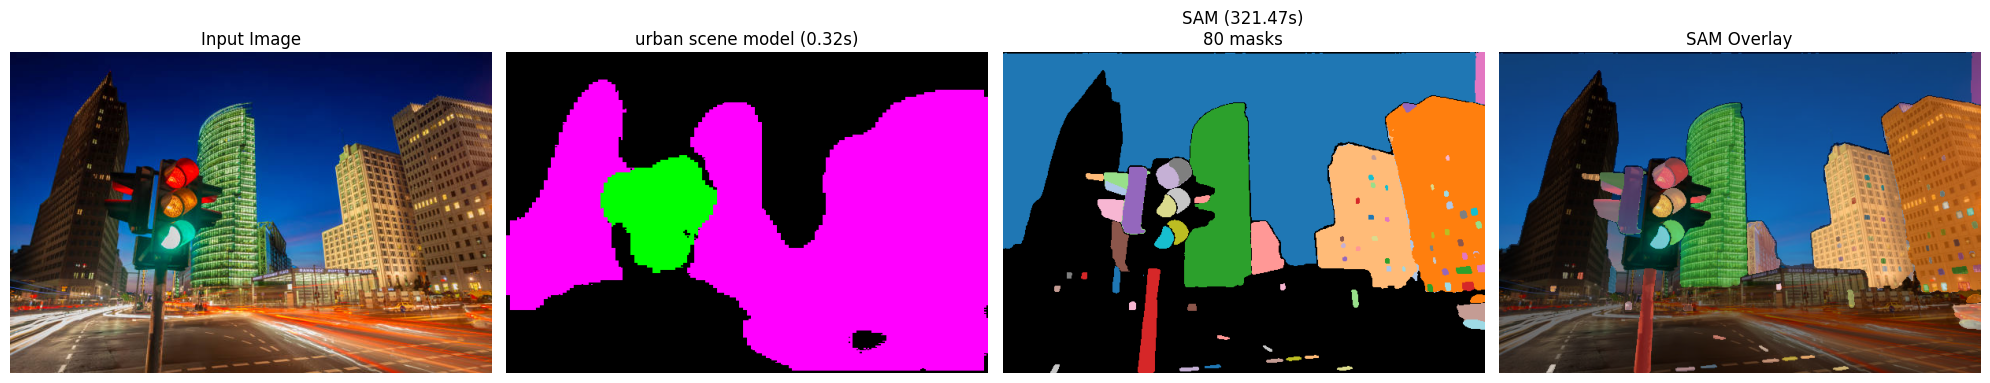

urban scene model: 0.32s | SAM: 321.47s | SAM masks: 80


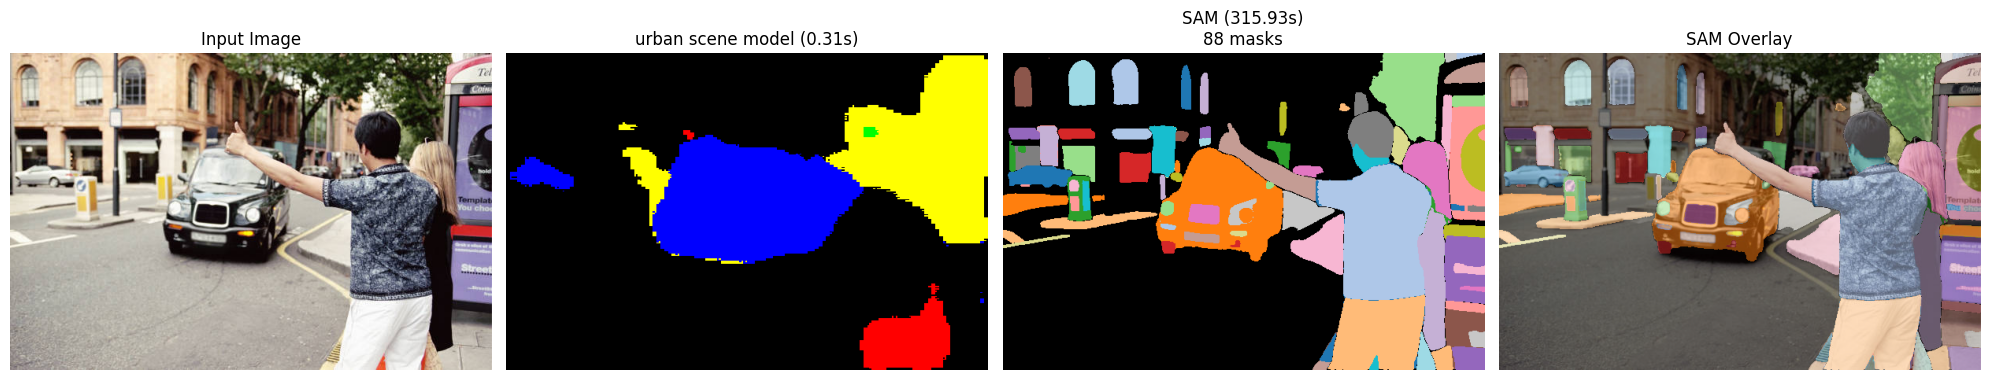

urban scene model: 0.31s | SAM: 315.93s | SAM masks: 88


In [ ]:
# test on some images
test_images = ["/content/test_1.jpg", "/content/test_2.jpg", "/content/test_3.jpg"]

for img_path in test_images:
    if os.path.exists(img_path):
        t, sam_t, n_masks = compare_with_sam(model, mask_generator, img_path, device)
        print(f"urban scene model: {t:.2f}s | SAM: {sam_t:.2f}s | SAM masks: {n_masks}")

SAM produces instance-level masks without semantic labels, requiring ~950x more inference time (321s vs. 0.27s, 313s vs. 0.33s). While SAM achieves much better boundary detail and can segment arbitrary objects, it over-segments the scene (80 masks) and provides no class information. For comparison, task-specific model directly outputs semantic labels at a fraction of the computational cost.